# Visualisation: Helpful Vote Prediction

**MSc Applied Artificial Intelligence — AI and Deep Learning Module**  
**WMG, University of Warwick — 2025/26**  
**Client: IntelliSys Ltd.**

---

## Problem Statement

Predict whether an Amazon Electronics review will receive at least one helpful vote from other customers.

**Task:** Binary classification  
**Target:** `helpful_binary` — 1 if `helpful_vote > 0`, else 0  
**Data:** 50,000 streamed reviews from Amazon Electronics (HuggingFace)

---

## Notebook Structure

| Section | Purpose |
|---|---|
| 1. Setup & Data Load | Reproduce dataset from `eda1.ipynb` |
| 2. Target Variable Analysis | Class balance, vote distribution |
| 3. Feature → Target Relationships | How each feature relates to helpfulness |
| 4. Text Characteristics | Length, word count, depth by class |
| 5. Temporal Patterns | Time-based helpfulness trends |
| 6. Rating Deep Dive | Rating skew, helpfulness by rating |
| 7. Verified Purchase Analysis | Trust signal impact |
| 8. Correlation & Feature Overview | Predictive signal summary |
| 9. Modelling Implications | Class imbalance, feature selection notes |

---
## 1. Setup & Data Load

In [1]:
import itertools
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datasets import load_dataset, Dataset
from tqdm import tqdm

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

PALETTE = {'helpful': '#2196F3', 'not_helpful': '#FF7043', 'neutral': '#78909C'}
CLASS_COLORS = [PALETTE['not_helpful'], PALETTE['helpful']]

SAMPLE_SIZE = 50_000
RANDOM_STATE = 42
REVIEWS_URL = (
    "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/"
    "resolve/main/raw/review_categories/Electronics.jsonl"
)

print(f'Configuration: {SAMPLE_SIZE:,} reviews | seed={RANDOM_STATE}')

/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Configuration: 50,000 reviews | seed=42


In [2]:
import os
CACHE_PATH = os.path.join(os.path.dirname(os.path.abspath('viz.ipynb')), 'electronics_50k.csv')

if os.path.exists(CACHE_PATH):
    print(f'Loading from cache...')
    df = pd.read_csv(CACHE_PATH)
    print(f'✓ Loaded {len(df):,} reviews from cache')
else:
    print(f'Streaming {SAMPLE_SIZE:,} reviews from HuggingFace...')
    ds_iter = load_dataset('json', data_files=REVIEWS_URL, split='train', streaming=True)
    sample  = list(tqdm(itertools.islice(ds_iter, SAMPLE_SIZE), total=SAMPLE_SIZE, desc='Loading'))
    df      = Dataset.from_list(sample).to_pandas()
    df = df.dropna(how='all')
    df = df[df['text'].notna() & (df['text'].str.strip().str.len() > 0)]
    df.to_csv(CACHE_PATH, index=False)
    print(f'✓ Saved to cache')

# --- Feature engineering ---
df['timestamp']      = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')
df['review_length']  = df['text'].str.len()
df['word_count']     = df['text'].str.split().str.len()
df['helpful_binary'] = (df['helpful_vote'] > 0).astype(int)
df['year']           = df['timestamp'].dt.year
df['rating_int']     = df['rating'].astype(int)
df['is_long']        = (df['word_count'] > 200).astype(int)
df['chars_per_word'] = df['review_length'] / df['word_count'].replace(0, np.nan)

def sentiment_label(r):
    if r <= 2: return 'Negative'
    if r == 3: return 'Neutral'
    return 'Positive'
df['sentiment'] = df['rating'].apply(sentiment_label)

print(f'\n✓ {len(df):,} reviews ready')
print(f'  Helpful (1): {df["helpful_binary"].sum():,} ({df["helpful_binary"].mean()*100:.1f}%)')
print(f'  Not Helpful (0): {(1-df["helpful_binary"]).sum():,} ({(1-df["helpful_binary"].mean())*100:.1f}%)')

Loading from cache...


✓ Loaded 49,991 reviews from cache



✓ 49,991 reviews ready
  Helpful (1): 12,823 (25.7%)
  Not Helpful (0): 37,168 (74.3%)


---
## 2. Target Variable Analysis

Understanding the class balance and raw `helpful_vote` distribution before binarisation.

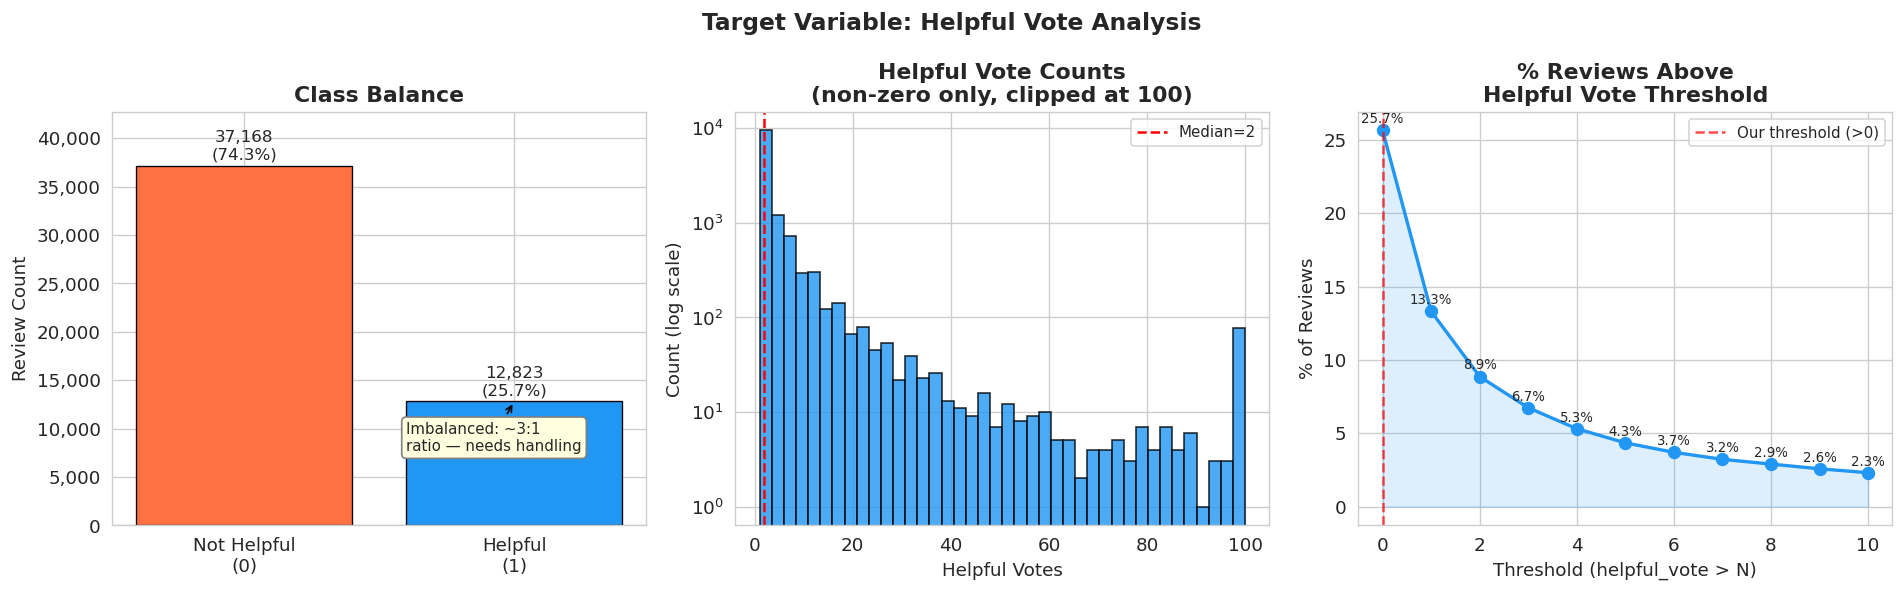


Class Imbalance Summary:
  Majority class (0): 74.3%
  Minority class (1): 25.7%
  Imbalance ratio:    2.90:1

→ Modelling note: consider class_weight="balanced", SMOTE, or focal loss.


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Target Variable: Helpful Vote Analysis', fontsize=14, fontweight='bold')

# --- 2a. Class balance ---
ax = axes[0]
counts = df['helpful_binary'].value_counts().sort_index()
bars = ax.bar(['Not Helpful\n(0)', 'Helpful\n(1)'], counts.values,
              color=CLASS_COLORS, edgecolor='black', linewidth=0.8)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{count:,}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('Class Balance', fontweight='bold')
ax.set_ylabel('Review Count')
ax.set_ylim(0, counts.max() * 1.15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.annotate('Imbalanced: ~3:1\nratio — needs handling',
            xy=(1, counts[1]), xytext=(0.6, counts[1] * 0.6),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

# --- 2b. Raw helpful_vote distribution (log, clipped) ---
ax = axes[1]
nonzero = df[df['helpful_vote'] > 0]['helpful_vote'].clip(upper=100)
ax.hist(nonzero, bins=40, color=PALETTE['helpful'], edgecolor='black', alpha=0.8)
ax.set_title('Helpful Vote Counts\n(non-zero only, clipped at 100)', fontweight='bold')
ax.set_xlabel('Helpful Votes')
ax.set_ylabel('Count (log scale)')
ax.set_yscale('log')
ax.axvline(df[df['helpful_vote']>0]['helpful_vote'].median(), color='red',
           linestyle='--', label=f'Median={df[df["helpful_vote"]>0]["helpful_vote"].median():.0f}')
ax.legend(fontsize=9)

# --- 2c. Cumulative helpful_vote threshold ---
ax = axes[2]
thresholds = range(0, 11)
pcts = [(df['helpful_vote'] > t).mean() * 100 for t in thresholds]
ax.plot(thresholds, pcts, 'o-', color=PALETTE['helpful'], linewidth=2, markersize=7)
ax.axvline(0, color='red', linestyle='--', alpha=0.7, label='Our threshold (>0)')
ax.fill_between(thresholds, pcts, alpha=0.15, color=PALETTE['helpful'])
for t, p in zip(thresholds, pcts):
    ax.text(t, p + 0.5, f'{p:.1f}%', ha='center', fontsize=8)
ax.set_title('% Reviews Above\nHelpful Vote Threshold', fontweight='bold')
ax.set_xlabel('Threshold (helpful_vote > N)')
ax.set_ylabel('% of Reviews')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\nClass Imbalance Summary:')
print(f'  Majority class (0): {(1-df["helpful_binary"].mean())*100:.1f}%')
print(f'  Minority class (1): {df["helpful_binary"].mean()*100:.1f}%')
print(f'  Imbalance ratio:    {(1-df["helpful_binary"].mean())/df["helpful_binary"].mean():.2f}:1')
print('\n→ Modelling note: consider class_weight="balanced", SMOTE, or focal loss.')

---
## 3. Feature → Target Relationships

How each feature distributes across the two classes.

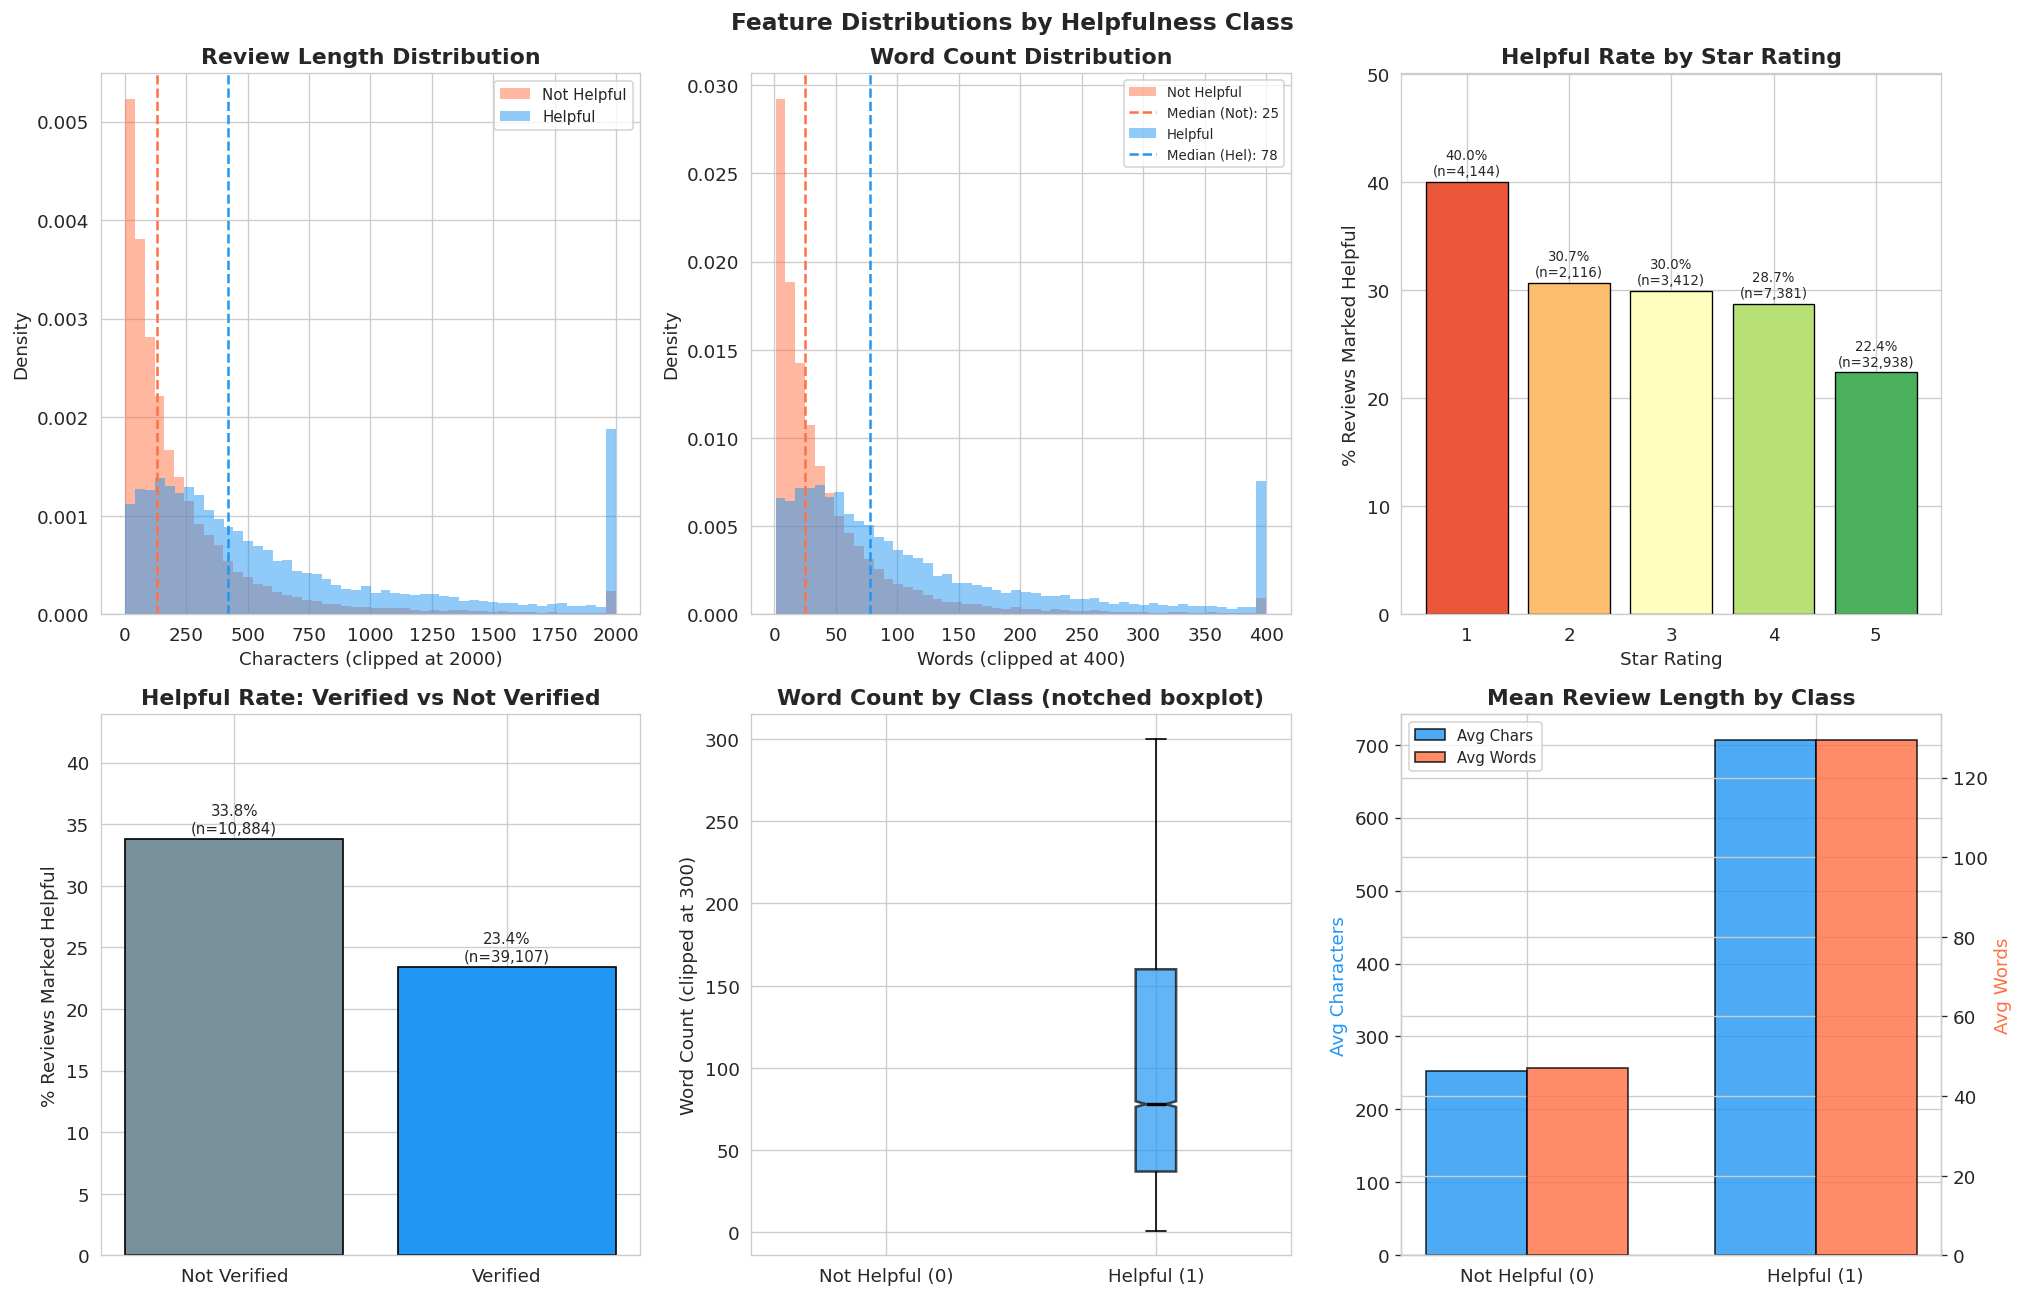

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(17, 11))
fig.suptitle('Feature Distributions by Helpfulness Class', fontsize=14, fontweight='bold')

helpful_0 = df[df['helpful_binary'] == 0]
helpful_1 = df[df['helpful_binary'] == 1]

# --- 3a. Review length by class (KDE) ---
ax = axes[0, 0]
for grp, label, color in [(helpful_0, 'Not Helpful', PALETTE['not_helpful']),
                           (helpful_1, 'Helpful',     PALETTE['helpful'])]:
    clipped = grp['review_length'].clip(upper=2000)
    ax.hist(clipped, bins=50, alpha=0.5, color=color, label=label, density=True, edgecolor='none')
    ax.axvline(grp['review_length'].median(), color=color, linestyle='--', linewidth=1.5)
ax.set_title('Review Length Distribution', fontweight='bold')
ax.set_xlabel('Characters (clipped at 2000)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

# --- 3b. Word count by class ---
ax = axes[0, 1]
for grp, label, color in [(helpful_0, 'Not Helpful', PALETTE['not_helpful']),
                           (helpful_1, 'Helpful',     PALETTE['helpful'])]:
    clipped = grp['word_count'].clip(upper=400)
    ax.hist(clipped, bins=50, alpha=0.5, color=color, label=label, density=True, edgecolor='none')
    ax.axvline(grp['word_count'].median(), color=color, linestyle='--', linewidth=1.5,
               label=f'Median ({label[:3]}): {grp["word_count"].median():.0f}')
ax.set_title('Word Count Distribution', fontweight='bold')
ax.set_xlabel('Words (clipped at 400)')
ax.set_ylabel('Density')
ax.legend(fontsize=8)

# --- 3c. Helpful rate by rating ---
ax = axes[0, 2]
helpful_rate = df.groupby('rating_int')['helpful_binary'].mean() * 100
count_by_rating = df.groupby('rating_int').size()
bars = ax.bar(helpful_rate.index, helpful_rate.values,
              color=[sns.color_palette('RdYlGn', 5)[i] for i in range(5)],
              edgecolor='black', linewidth=0.8)
for bar, rate, count in zip(bars, helpful_rate.values, count_by_rating.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{rate:.1f}%\n(n={count:,})', ha='center', va='bottom', fontsize=8)
ax.set_title('Helpful Rate by Star Rating', fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('% Reviews Marked Helpful')
ax.set_ylim(0, helpful_rate.max() * 1.25)

# --- 3d. Verified purchase helpfulness rate ---
ax = axes[1, 0]
vp_rate = df.groupby('verified_purchase')['helpful_binary'].agg(['mean', 'count']).reset_index()
vp_rate.columns = ['verified', 'rate', 'count']
vp_rate['label'] = vp_rate['verified'].map({True: 'Verified', False: 'Not Verified'})
vp_rate['pct'] = vp_rate['rate'] * 100
bars = ax.bar(vp_rate['label'], vp_rate['pct'],
              color=[PALETTE['neutral'], PALETTE['helpful']], edgecolor='black')
for bar, row in zip(bars, vp_rate.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{row.pct:.1f}%\n(n={row.count:,})', ha='center', va='bottom', fontsize=9)
ax.set_title('Helpful Rate: Verified vs Not Verified', fontweight='bold')
ax.set_ylabel('% Reviews Marked Helpful')
ax.set_ylim(0, vp_rate['pct'].max() * 1.3)

# --- 3e. Review length boxplot by class ---
ax = axes[1, 1]
bp_data = [helpful_0['word_count'].clip(upper=300).values,
           helpful_1['word_count'].clip(upper=300).values]
bp = ax.boxplot(bp_data, labels=['Not Helpful (0)', 'Helpful (1)'],
                patch_artist=True, notch=True,
                boxprops=dict(linewidth=1.5),
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], CLASS_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Word Count by Class (notched boxplot)', fontweight='bold')
ax.set_ylabel('Word Count (clipped at 300)')

# --- 3f. Mean review length and word count by class (summary bar) ---
ax = axes[1, 2]
metrics = df.groupby('helpful_binary')[['review_length', 'word_count']].mean()
x = np.arange(2)
width = 0.35
b1 = ax.bar(x - width/2, metrics['review_length'], width, label='Avg Chars',
            color=PALETTE['helpful'], alpha=0.8, edgecolor='black')
ax2 = ax.twinx()
b2 = ax2.bar(x + width/2, metrics['word_count'], width, label='Avg Words',
             color=PALETTE['not_helpful'], alpha=0.8, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['Not Helpful (0)', 'Helpful (1)'])
ax.set_ylabel('Avg Characters', color=PALETTE['helpful'])
ax2.set_ylabel('Avg Words', color=PALETTE['not_helpful'])
ax.set_title('Mean Review Length by Class', fontweight='bold')
lines = [b1, b2]
ax.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---
## 4. Text Characteristics

Deeper look at review text depth across ratings and helpfulness classes.

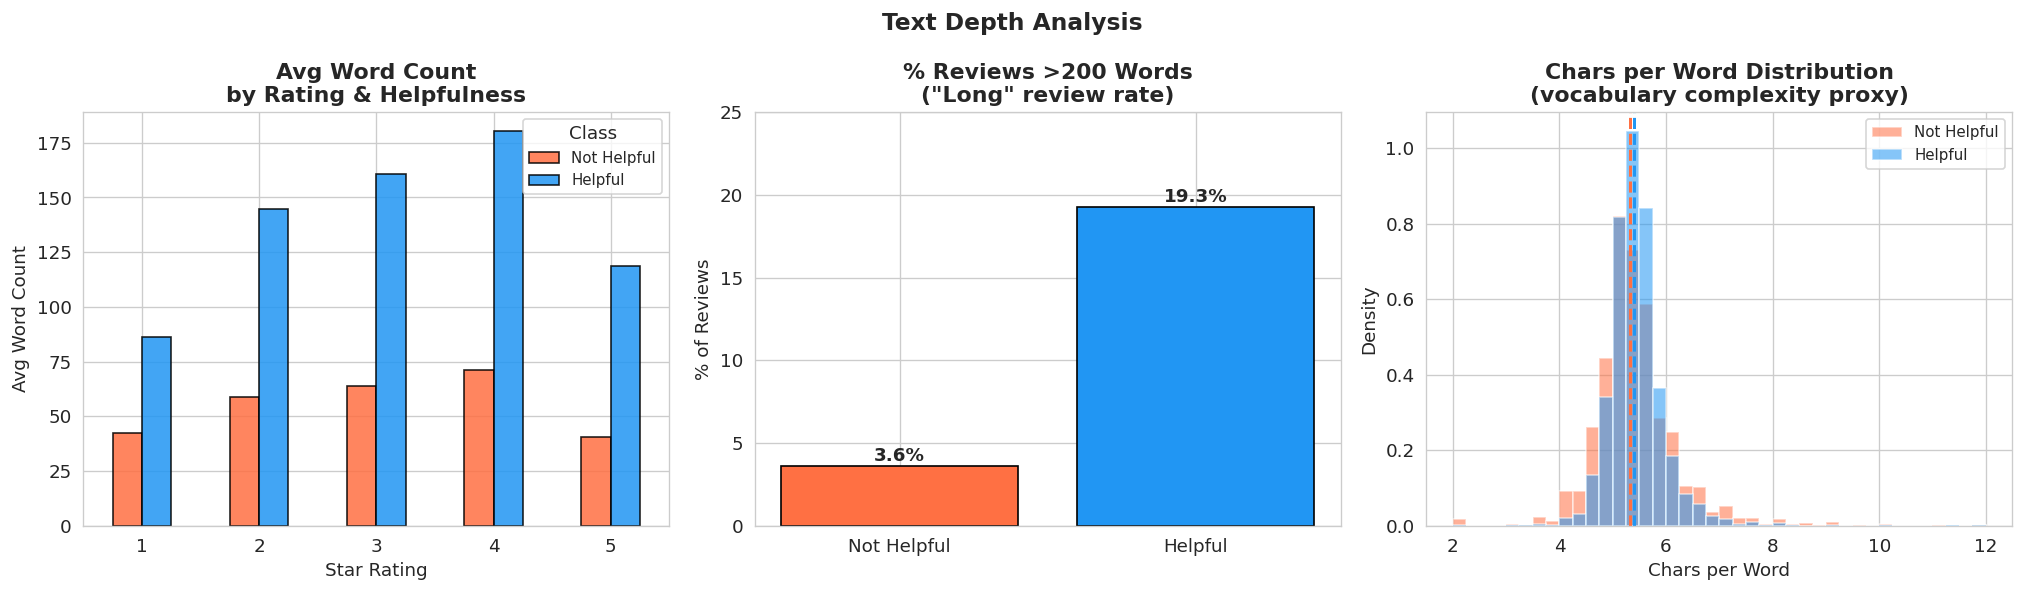

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Text Depth Analysis', fontsize=14, fontweight='bold')

# --- 4a. Avg word count by rating × helpfulness ---
ax = axes[0]
pivot = df.groupby(['rating_int', 'helpful_binary'])['word_count'].mean().unstack()
pivot.columns = ['Not Helpful', 'Helpful']
pivot.plot(kind='bar', ax=ax, color=CLASS_COLORS, edgecolor='black', alpha=0.85)
ax.set_title('Avg Word Count\nby Rating & Helpfulness', fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Avg Word Count')
ax.set_xticklabels(pivot.index, rotation=0)
ax.legend(title='Class', fontsize=9)

# --- 4b. Long review rate (>200 words) by class ---
ax = axes[1]
long_rate = df.groupby('helpful_binary')['is_long'].mean() * 100
bars = ax.bar(['Not Helpful', 'Helpful'], long_rate.values,
              color=CLASS_COLORS, edgecolor='black')
for bar, val in zip(bars, long_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('% Reviews >200 Words\n("Long" review rate)', fontweight='bold')
ax.set_ylabel('% of Reviews')
ax.set_ylim(0, long_rate.max() * 1.3)

# --- 4c. Chars per word (depth proxy) ---
ax = axes[2]
for grp, label, color in [(helpful_0, 'Not Helpful', PALETTE['not_helpful']),
                           (helpful_1, 'Helpful',     PALETTE['helpful'])]:
    clipped = grp['chars_per_word'].dropna().clip(2, 12)
    ax.hist(clipped, bins=40, alpha=0.55, color=color, label=label, density=True)
    ax.axvline(clipped.median(), color=color, linestyle='--', linewidth=1.8)
ax.set_title('Chars per Word Distribution\n(vocabulary complexity proxy)', fontweight='bold')
ax.set_xlabel('Chars per Word')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Temporal Patterns

Review volume and helpfulness rates over time. Note: older reviews naturally accumulate more votes — important for model fairness.

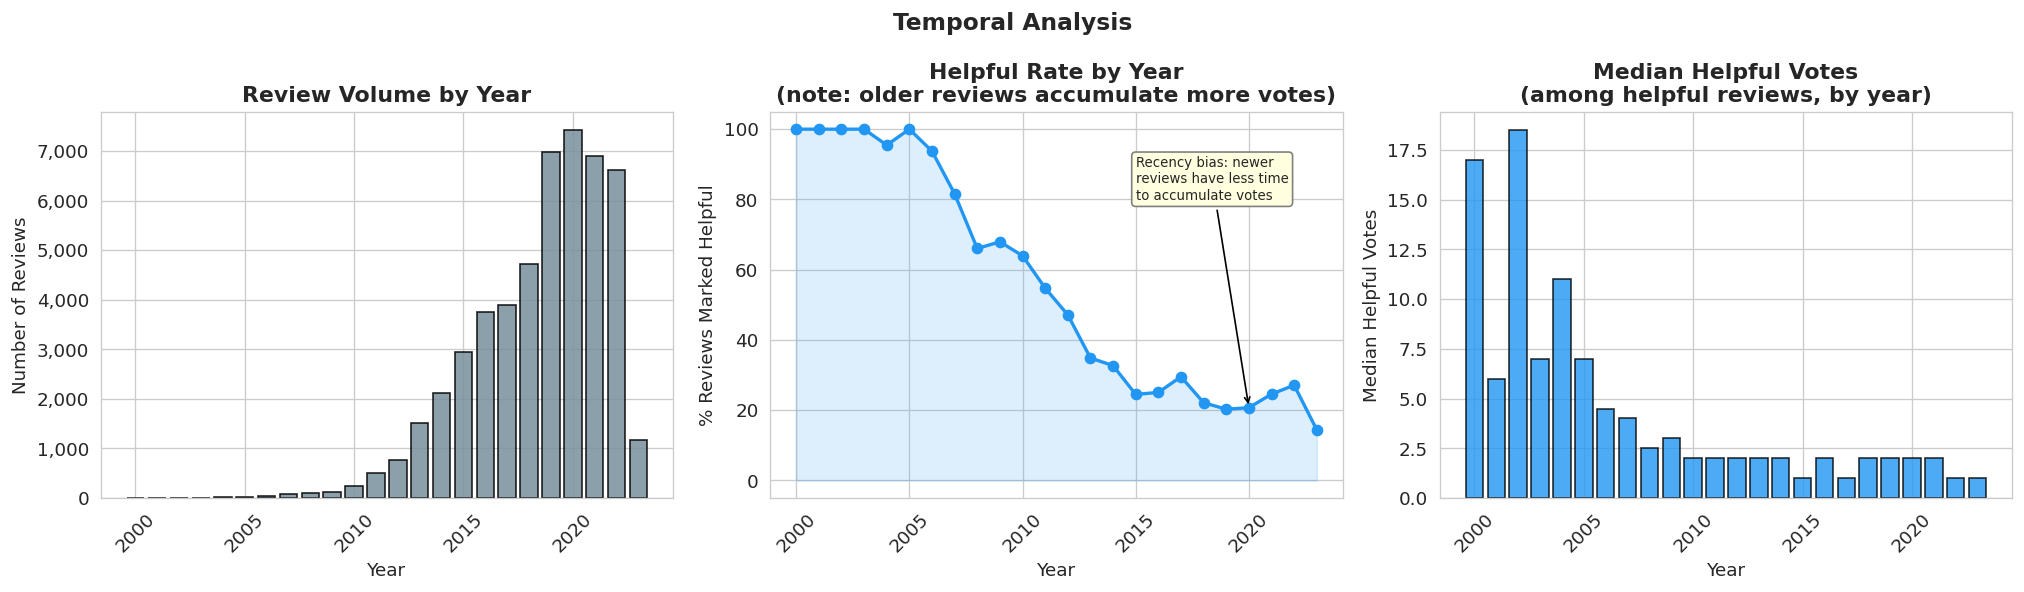


→ Modelling note: consider using year as a feature or applying temporal train/test split.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Temporal Analysis', fontsize=14, fontweight='bold')

year_df = df[df['year'].between(2000, 2023)]

# --- 5a. Review volume per year ---
ax = axes[0]
vol = year_df.groupby('year').size()
ax.bar(vol.index, vol.values, color=PALETTE['neutral'], edgecolor='black', alpha=0.85)
ax.set_title('Review Volume by Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)

# --- 5b. Helpful rate by year ---
ax = axes[1]
helpful_by_year = year_df.groupby('year')['helpful_binary'].mean() * 100
ax.plot(helpful_by_year.index, helpful_by_year.values, 'o-',
        color=PALETTE['helpful'], linewidth=2, markersize=6)
ax.fill_between(helpful_by_year.index, helpful_by_year.values, alpha=0.15, color=PALETTE['helpful'])
ax.set_title('Helpful Rate by Year\n(note: older reviews accumulate more votes)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% Reviews Marked Helpful')
ax.tick_params(axis='x', rotation=45)
ax.annotate('Recency bias: newer\nreviews have less time\nto accumulate votes',
            xy=(2020, helpful_by_year.get(2020, helpful_by_year.iloc[-3])),
            xytext=(2015, helpful_by_year.max() * 0.8),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

# --- 5c. Avg helpful votes by year (non-zero only) ---
ax = axes[2]
nz = year_df[year_df['helpful_vote'] > 0]
avg_votes = nz.groupby('year')['helpful_vote'].median()
ax.bar(avg_votes.index, avg_votes.values, color=PALETTE['helpful'], edgecolor='black', alpha=0.8)
ax.set_title('Median Helpful Votes\n(among helpful reviews, by year)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Median Helpful Votes')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('\n→ Modelling note: consider using year as a feature or applying temporal train/test split.')

---
## 6. Rating Deep Dive

Sentiment categories and how rating interacts with helpfulness.

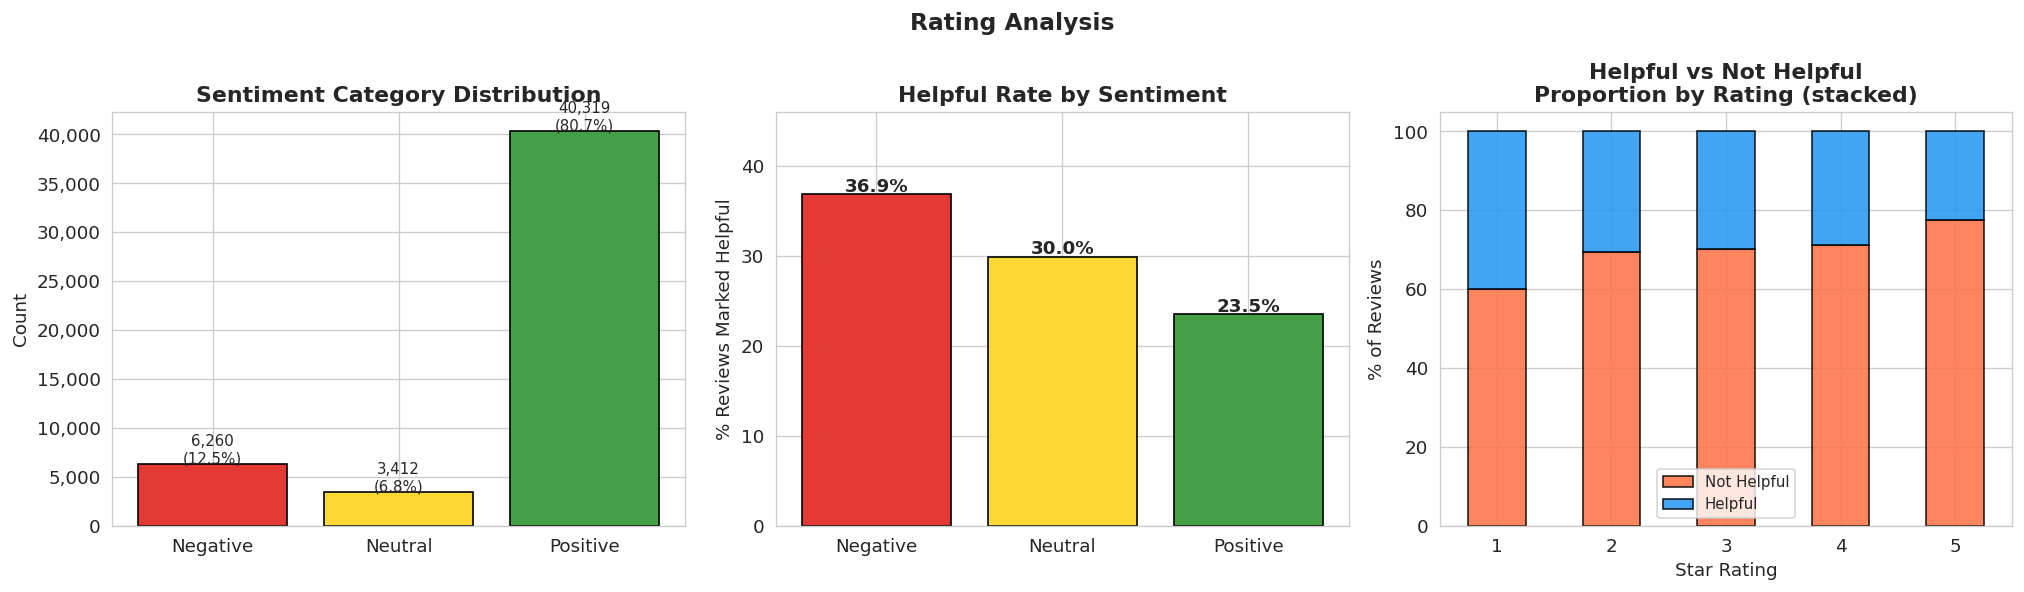

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Rating Analysis', fontsize=14, fontweight='bold')

sentiment_colors = {'Negative': '#E53935', 'Neutral': '#FDD835', 'Positive': '#43A047'}

# --- 6a. Sentiment class distribution ---
ax = axes[0]
sent_counts = df['sentiment'].value_counts()[['Negative', 'Neutral', 'Positive']]
bars = ax.bar(sent_counts.index, sent_counts.values,
              color=[sentiment_colors[s] for s in sent_counts.index],
              edgecolor='black')
for bar, cnt in zip(bars, sent_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f'{cnt:,}\n({cnt/len(df)*100:.1f}%)', ha='center', fontsize=9)
ax.set_title('Sentiment Category Distribution', fontweight='bold')
ax.set_ylabel('Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# --- 6b. Helpful rate by sentiment ---
ax = axes[1]
hr_sent = df.groupby('sentiment')['helpful_binary'].mean() * 100
hr_sent = hr_sent[['Negative', 'Neutral', 'Positive']]
bars = ax.bar(hr_sent.index, hr_sent.values,
              color=[sentiment_colors[s] for s in hr_sent.index], edgecolor='black')
for bar, val in zip(bars, hr_sent.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set_title('Helpful Rate by Sentiment', fontweight='bold')
ax.set_ylabel('% Reviews Marked Helpful')
ax.set_ylim(0, hr_sent.max() * 1.25)

# --- 6c. Stacked bar: helpful vs not by rating ---
ax = axes[2]
pivot2 = df.groupby('rating_int')['helpful_binary'].value_counts(normalize=True).unstack() * 100
pivot2.columns = ['Not Helpful', 'Helpful']
pivot2[['Not Helpful', 'Helpful']].plot(
    kind='bar', stacked=True, ax=ax,
    color=CLASS_COLORS, edgecolor='black', alpha=0.85
)
ax.set_title('Helpful vs Not Helpful\nProportion by Rating (stacked)', fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('% of Reviews')
ax.set_xticklabels(pivot2.index, rotation=0)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 7. Verified Purchase Analysis

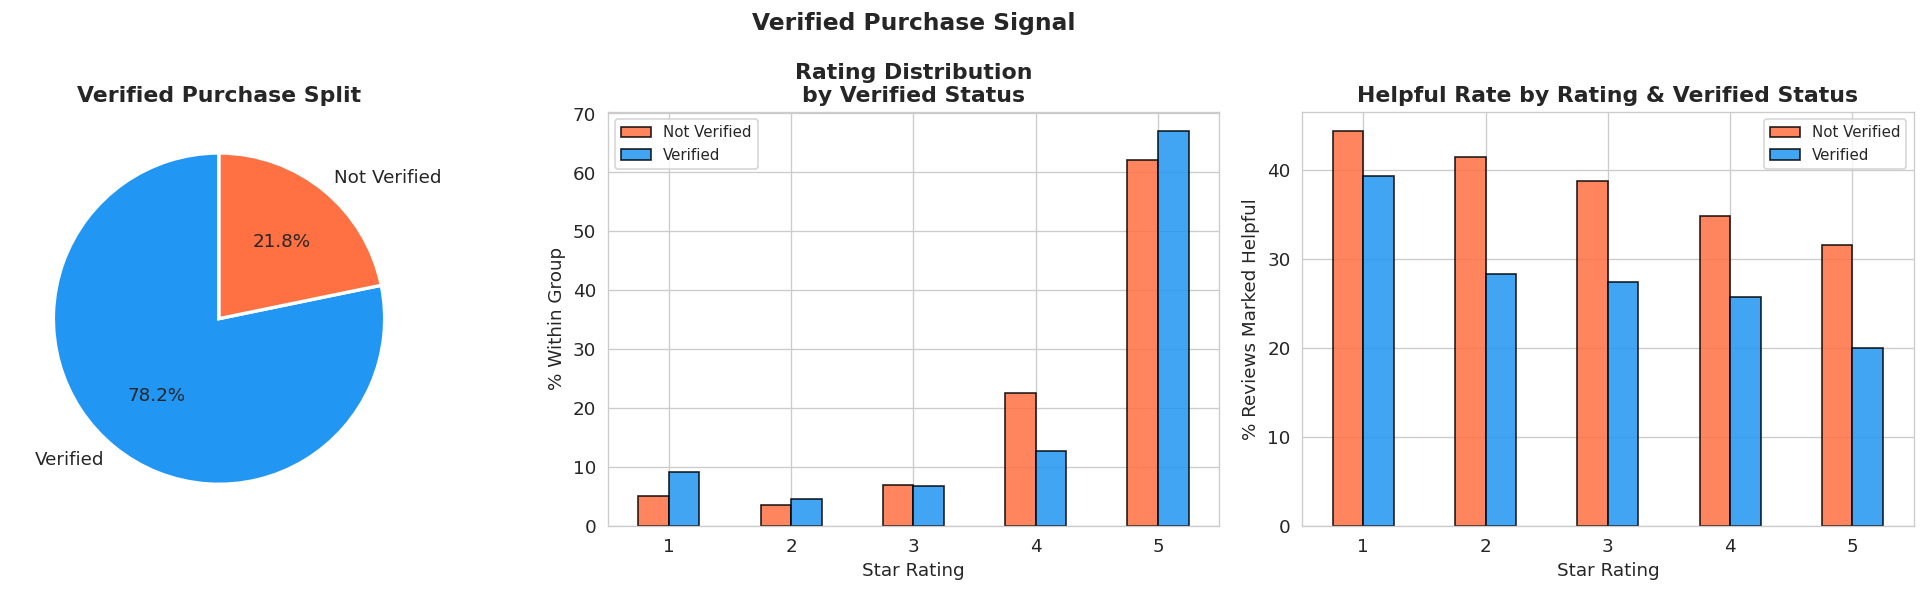

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Verified Purchase Signal', fontsize=14, fontweight='bold')

# --- 7a. Verified purchase split ---
ax = axes[0]
vp_counts = df['verified_purchase'].value_counts()
ax.pie(vp_counts.values,
       labels=['Verified', 'Not Verified'],
       autopct='%1.1f%%',
       colors=[PALETTE['helpful'], PALETTE['not_helpful']],
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Verified Purchase Split', fontweight='bold')

# --- 7b. Rating distribution by verified ---
ax = axes[1]
vp_rating = df.groupby(['verified_purchase', 'rating_int']).size().unstack().T
vp_rating.columns = ['Not Verified', 'Verified']
vp_rating_pct = vp_rating.div(vp_rating.sum()) * 100
vp_rating_pct.plot(kind='bar', ax=ax, color=[PALETTE['not_helpful'], PALETTE['helpful']],
                   edgecolor='black', alpha=0.85)
ax.set_title('Rating Distribution\nby Verified Status', fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('% Within Group')
ax.set_xticklabels(vp_rating_pct.index, rotation=0)
ax.legend(fontsize=9)

# --- 7c. Helpfulness rate by verified × rating ---
ax = axes[2]
hr_vr = df.groupby(['verified_purchase', 'rating_int'])['helpful_binary'].mean() * 100
hr_vr = hr_vr.unstack(level=0)
hr_vr.columns = ['Not Verified', 'Verified']
hr_vr.plot(kind='bar', ax=ax,
           color=[PALETTE['not_helpful'], PALETTE['helpful']],
           edgecolor='black', alpha=0.85)
ax.set_title('Helpful Rate by Rating & Verified Status', fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('% Reviews Marked Helpful')
ax.set_xticklabels(hr_vr.index, rotation=0)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## 8. Correlation & Feature Signal Summary

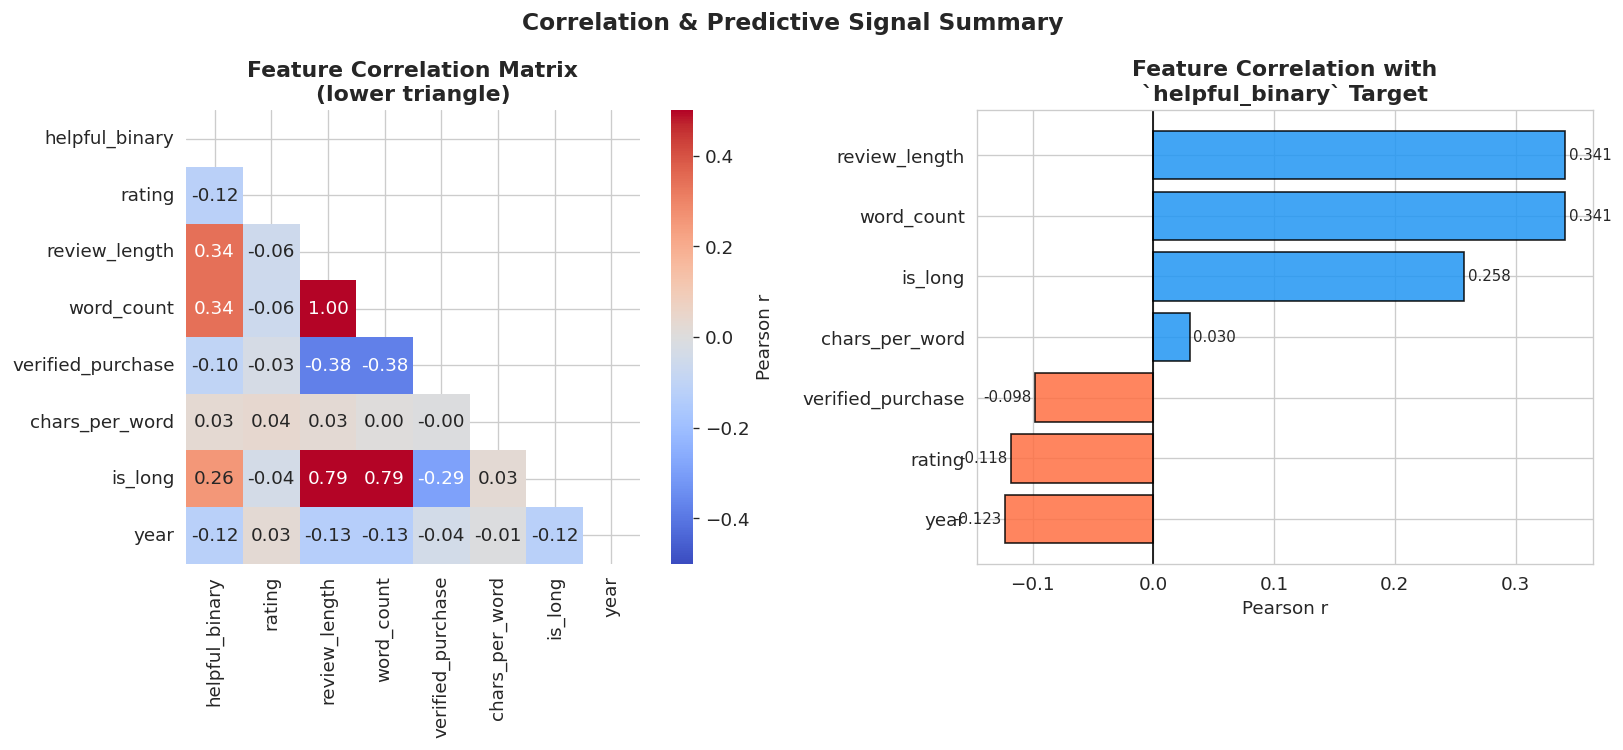


Correlations with helpful_binary (sorted):
  review_length       : +0.3412  ↑
  word_count          : +0.3410  ↑
  is_long             : +0.2576  ↑
  chars_per_word      : +0.0302  ↑
  verified_purchase   : -0.0982  ↓
  rating              : -0.1176  ↓
  year                : -0.1231  ↓


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Correlation & Predictive Signal Summary', fontsize=14, fontweight='bold')

# --- 8a. Correlation heatmap (target-focused) ---
ax = axes[0]
num_cols = ['helpful_binary', 'rating', 'review_length', 'word_count',
            'verified_purchase', 'chars_per_word', 'is_long', 'year']
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, square=True,
            cbar_kws={'label': 'Pearson r'},
            vmin=-0.5, vmax=0.5)
ax.set_title('Feature Correlation Matrix\n(lower triangle)', fontweight='bold')

# --- 8b. Bar chart: correlation with helpful_binary ---
ax = axes[1]
target_corr = corr['helpful_binary'].drop('helpful_binary').sort_values()
colors = [PALETTE['helpful'] if v > 0 else PALETTE['not_helpful'] for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
for bar, val in zip(bars, target_corr.values):
    offset = 0.003 if val >= 0 else -0.003
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)
ax.set_title('Feature Correlation with\n`helpful_binary` Target', fontweight='bold')
ax.set_xlabel('Pearson r')

plt.tight_layout()
plt.show()

print('\nCorrelations with helpful_binary (sorted):')
for feat, val in target_corr.sort_values(ascending=False).items():
    direction = '↑' if val > 0 else '↓'
    print(f'  {feat:20s}: {val:+.4f}  {direction}')

---
## 9. NLP Text Exploration

Top words per helpfulness class — core signal for any text-based model.

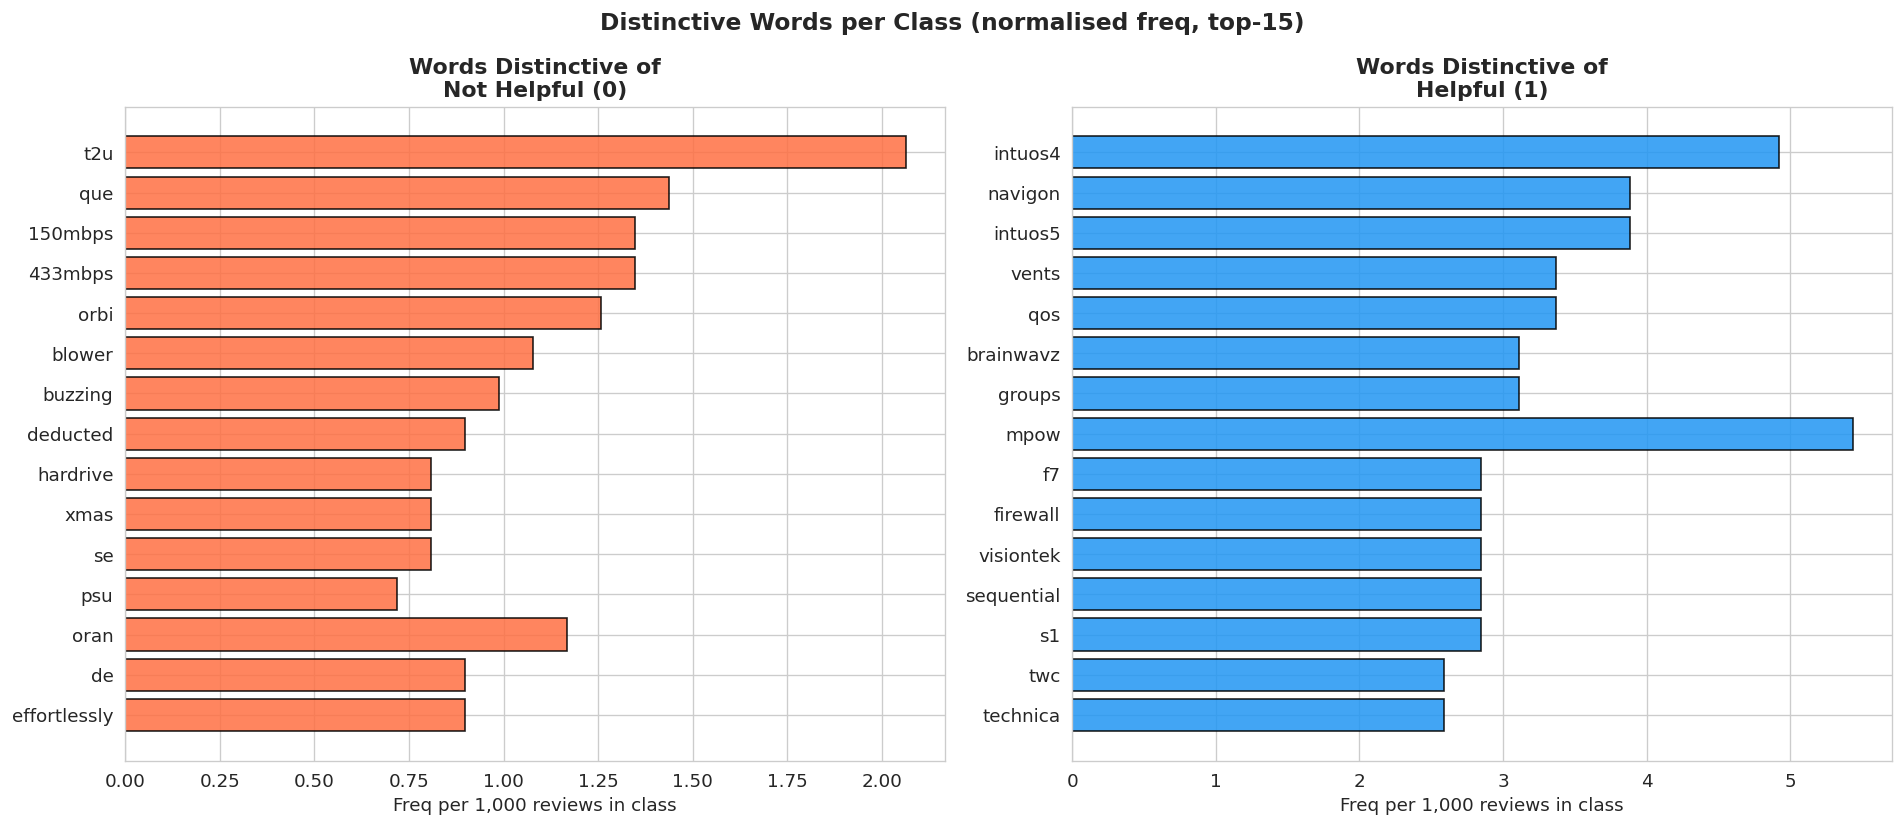

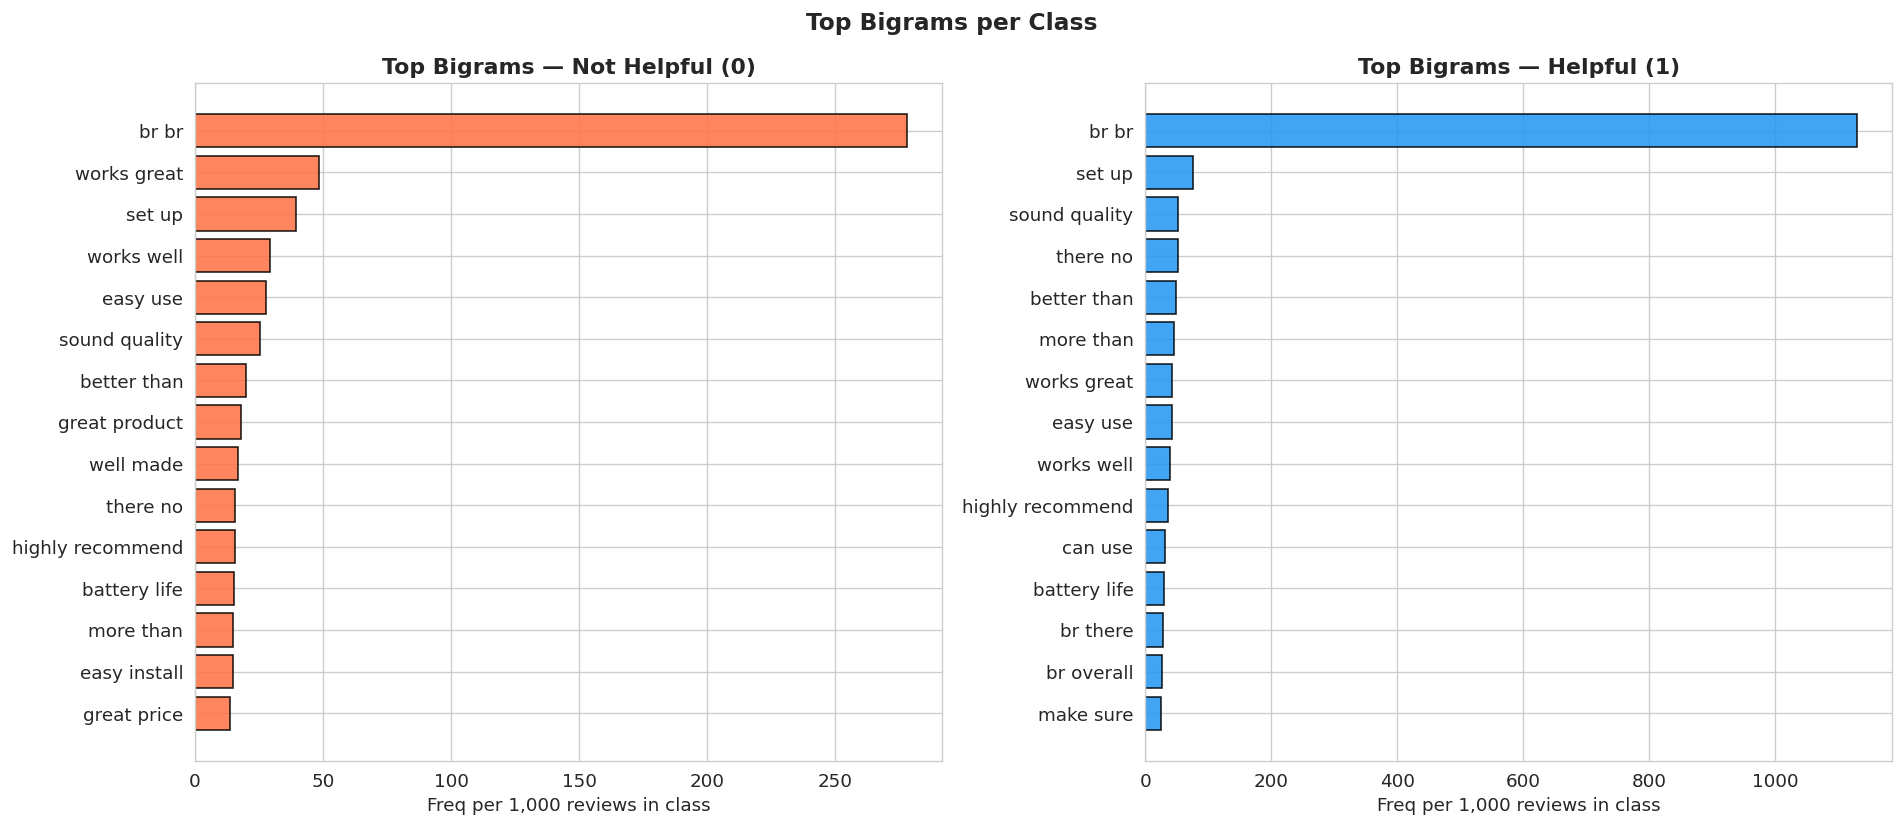

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
import re

STOPWORDS = [
    'i','me','my','we','our','you','your','he','she','it','its','they','them',
    'what','this','that','these','those','am','is','are','was','were','be',
    'been','have','has','had','do','does','did','will','would','could','should',
    'to','of','in','for','on','with','at','by','from','a','an','the','and',
    'but','if','or','as','so','not','just','also','very','so','too','then',
    's','t','re','ve','ll','d','m','got','get','got','even','really','much',
]

df_sample = df.sample(min(15000, len(df)), random_state=RANDOM_STATE)

def top_words_per_class(df_s, n=20):
    results = {}
    for cls in [0, 1]:
        texts = df_s[df_s['helpful_binary'] == cls]['text'].tolist()
        vec = CountVectorizer(max_features=3000, stop_words=STOPWORDS,
                              ngram_range=(1,1), min_df=5)
        X = vec.fit_transform(texts)
        freq = X.sum(axis=0).A1
        vocab = vec.get_feature_names_out()
        top_idx = freq.argsort()[::-1][:n]
        results[cls] = [(vocab[i], freq[i] / len(texts) * 1000) for i in top_idx]
    return results

top = top_words_per_class(df_sample)

# Distinctive words: present in one class but rare in the other
def distinctive_words(df_s, target_cls, n=15):
    texts_t = df_s[df_s['helpful_binary'] == target_cls]['text'].tolist()
    texts_o = df_s[df_s['helpful_binary'] != target_cls]['text'].tolist()
    vec = CountVectorizer(max_features=5000, stop_words=STOPWORDS, min_df=3)
    vec.fit(texts_t + texts_o)
    vocab = vec.get_feature_names_out()
    freq_t = vec.transform(texts_t).sum(axis=0).A1 / max(len(texts_t), 1) * 1000
    freq_o = vec.transform(texts_o).sum(axis=0).A1 / max(len(texts_o), 1) * 1000
    ratio  = freq_t / (freq_o + 0.1)
    top_idx = ratio.argsort()[::-1][:n]
    return [(vocab[i], freq_t[i], ratio[i]) for i in top_idx]

dist_0 = distinctive_words(df_sample, 0)
dist_1 = distinctive_words(df_sample, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Distinctive Words per Class (normalised freq, top-15)', fontsize=14, fontweight='bold')

for ax, data, label, color in [
    (axes[0], dist_0, 'Not Helpful (0)', PALETTE['not_helpful']),
    (axes[1], dist_1, 'Helpful (1)',     PALETTE['helpful'])]:
    words  = [d[0] for d in data]
    freqs  = [d[1] for d in data]
    ax.barh(list(reversed(words)), list(reversed(freqs)), color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'Words Distinctive of\n{label}', fontweight='bold')
    ax.set_xlabel('Freq per 1,000 reviews in class')

plt.tight_layout()
plt.show()

# Bigrams
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))
fig2.suptitle('Top Bigrams per Class', fontsize=14, fontweight='bold')

for ax, cls, label, color in [
    (axes2[0], 0, 'Not Helpful (0)', PALETTE['not_helpful']),
    (axes2[1], 1, 'Helpful (1)',     PALETTE['helpful'])]:
    texts = df_sample[df_sample['helpful_binary'] == cls]['text'].tolist()
    vec2  = CountVectorizer(max_features=5000, stop_words=STOPWORDS,
                            ngram_range=(2,2), min_df=5)
    X2    = vec2.fit_transform(texts)
    freq2 = X2.sum(axis=0).A1
    vocab2 = vec2.get_feature_names_out()
    top_idx2 = freq2.argsort()[::-1][:15]
    top_bigrams = [(vocab2[i], freq2[i] / len(texts) * 1000) for i in top_idx2]
    words2  = [b[0] for b in top_bigrams]
    freqs2  = [b[1] for b in top_bigrams]
    ax.barh(list(reversed(words2)), list(reversed(freqs2)), color=color, edgecolor='black', alpha=0.85)
    ax.set_title(f'Top Bigrams — {label}', fontweight='bold')
    ax.set_xlabel('Freq per 1,000 reviews in class')

plt.tight_layout()
plt.show()

---
## 10. Mutual Information & Feature Importance Proxy

Mutual information captures non-linear relationships — more honest than Pearson r for binary classification.

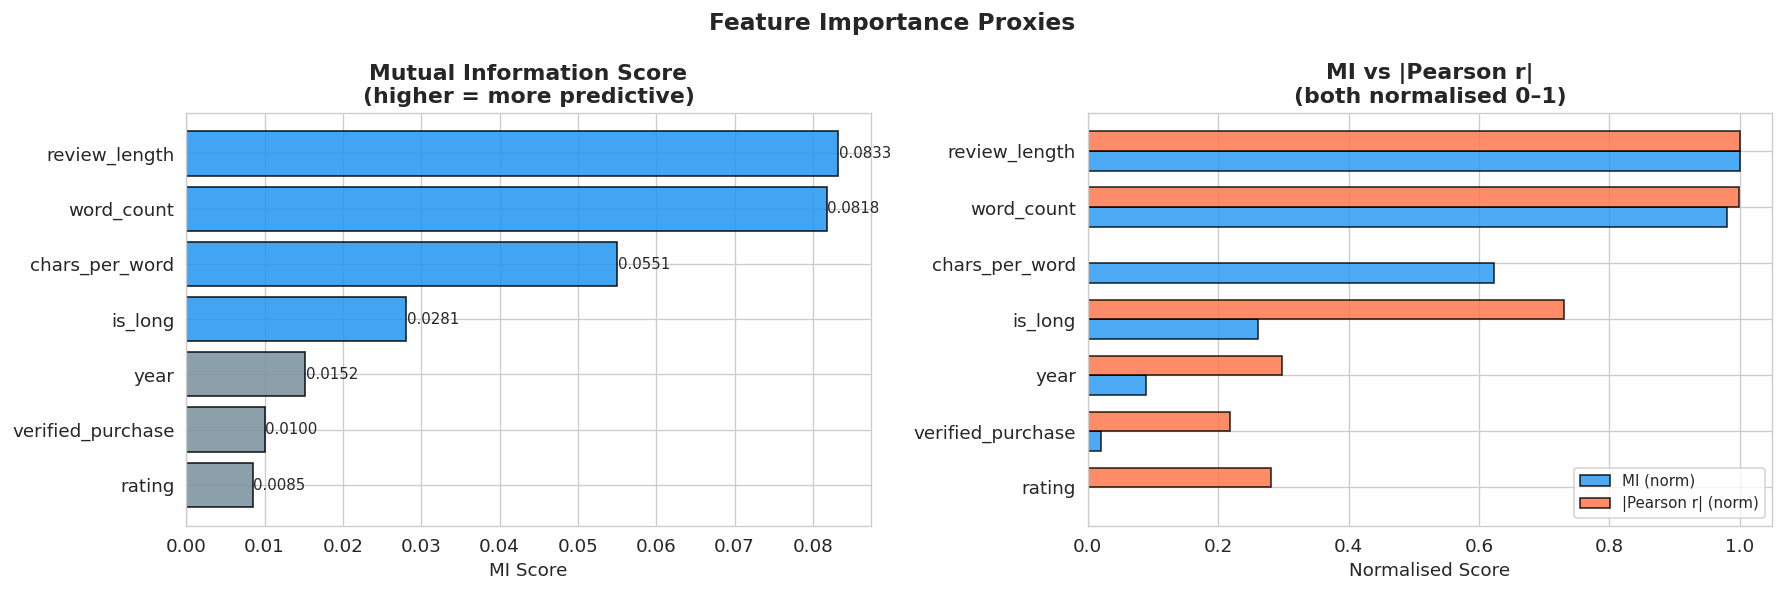


Feature ranking by Mutual Information:
  review_length       : 0.0833  ████████████████████
  word_count          : 0.0818  ███████████████████
  chars_per_word      : 0.0551  █████████████
  is_long             : 0.0281  ██████
  year                : 0.0152  ███
  verified_purchase   : 0.0100  ██
  rating              : 0.0085  ██


In [11]:
from sklearn.feature_selection import mutual_info_classif

feature_cols = ['rating', 'review_length', 'word_count', 'verified_purchase',
                'chars_per_word', 'is_long', 'year']

X_mi = df[feature_cols].copy()
X_mi['verified_purchase'] = X_mi['verified_purchase'].astype(int)
X_mi = X_mi.fillna(X_mi.median(numeric_only=True))
y_mi = df['helpful_binary']

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE)
mi_s = pd.Series(mi_scores, index=feature_cols).sort_values()

# Absolute Pearson r for comparison
pearson = df[feature_cols + ['helpful_binary']].copy()
pearson['verified_purchase'] = pearson['verified_purchase'].astype(int)
pearson_r = pearson.corr()['helpful_binary'].drop('helpful_binary').abs().reindex(mi_s.index)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Feature Importance Proxies', fontsize=14, fontweight='bold')

# MI bar
ax = axes[0]
colors = [PALETTE['helpful'] if v >= mi_s.median() else PALETTE['neutral'] for v in mi_s.values]
bars = ax.barh(mi_s.index, mi_s.values, color=colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, mi_s.values):
    ax.text(val + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Mutual Information Score\n(higher = more predictive)', fontweight='bold')
ax.set_xlabel('MI Score')

# MI vs Pearson normalised
ax = axes[1]
mi_n = (mi_s - mi_s.min()) / (mi_s.max() - mi_s.min())
pr_n = (pearson_r - pearson_r.min()) / (pearson_r.max() - pearson_r.min())
x = np.arange(len(feature_cols))
width = 0.35
ax.barh(x - width/2, mi_n.values,    width, label='MI (norm)',        color=PALETTE['helpful'],     alpha=0.8, edgecolor='black')
ax.barh(x + width/2, pr_n.values,    width, label='|Pearson r| (norm)', color=PALETTE['not_helpful'], alpha=0.8, edgecolor='black')
ax.set_yticks(x)
ax.set_yticklabels(mi_s.index)
ax.set_title('MI vs |Pearson r|\n(both normalised 0–1)', fontweight='bold')
ax.set_xlabel('Normalised Score')
ax.legend(fontsize=9)
ax.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

print('\nFeature ranking by Mutual Information:')
for feat, val in mi_s.sort_values(ascending=False).items():
    bar = '█' * int(val / mi_s.max() * 20)
    print(f'  {feat:20s}: {val:.4f}  {bar}')

---
## 11. Feature Interaction Effects

Does a *long negative review* get more helpful votes than a *short negative review*? These interactions are real predictive signal.

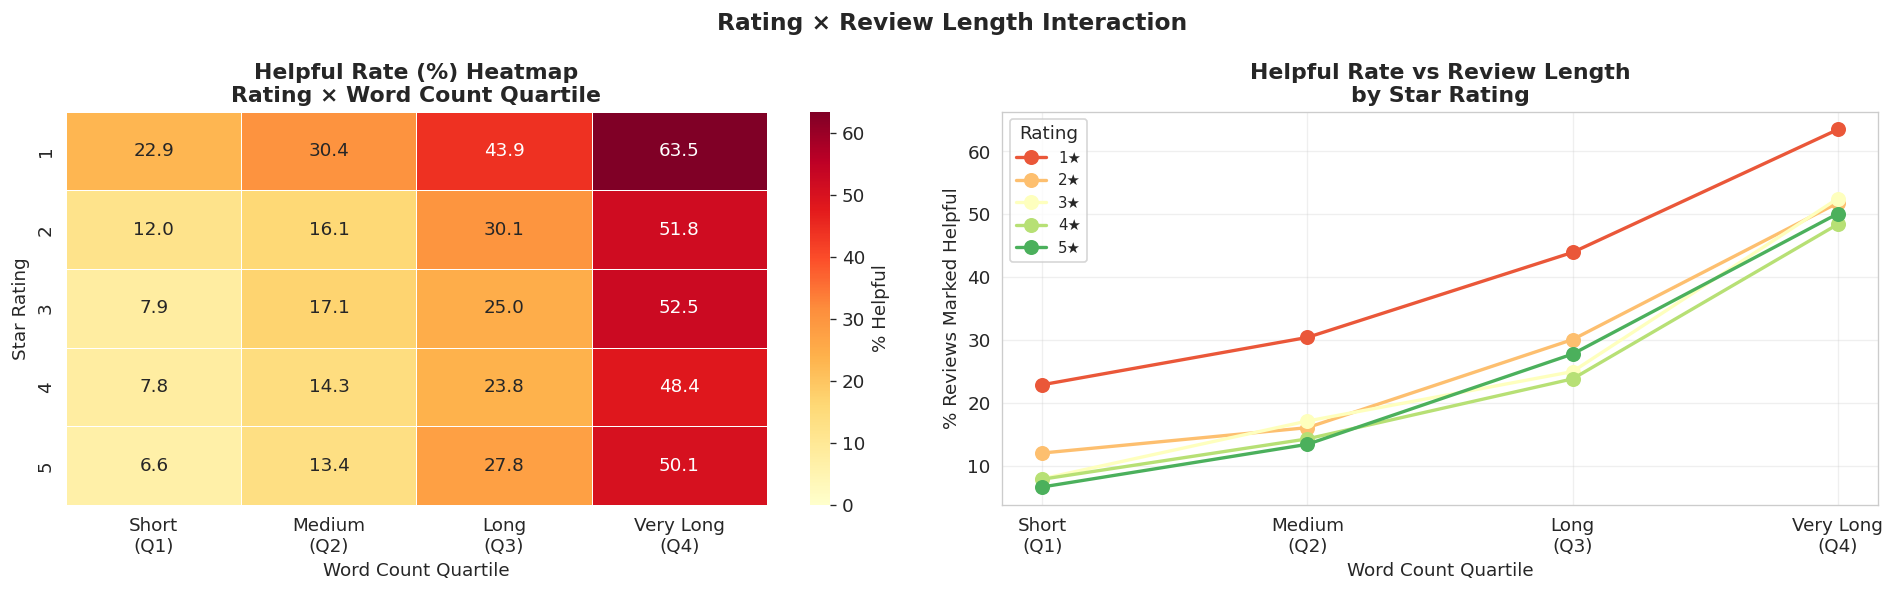


Key interaction insight:
  Short + 1★:     22.9% helpful
  Very Long + 1★: 63.5% helpful
  Short + 5★:     6.6% helpful
  Very Long + 5★: 50.1% helpful


In [12]:
df['length_bin'] = pd.qcut(df['word_count'], q=4,
                            labels=['Short\n(Q1)', 'Medium\n(Q2)', 'Long\n(Q3)', 'Very Long\n(Q4)'])

pivot_ix = df.groupby(['rating_int', 'length_bin'], observed=True)['helpful_binary'].mean().unstack() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Rating × Review Length Interaction', fontsize=14, fontweight='bold')

# Heatmap
ax = axes[0]
sns.heatmap(pivot_ix, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': '% Helpful'}, linewidths=0.5,
            vmin=0, vmax=pivot_ix.values.max())
ax.set_title('Helpful Rate (%) Heatmap\nRating × Word Count Quartile', fontweight='bold')
ax.set_xlabel('Word Count Quartile')
ax.set_ylabel('Star Rating')

# Line plot: length effect per rating
ax = axes[1]
cmap_r = sns.color_palette('RdYlGn', 5)
for i, rating in enumerate(sorted(df['rating_int'].unique())):
    row = pivot_ix.loc[rating]
    ax.plot(range(len(row)), row.values, 'o-', color=cmap_r[i],
            label=f'{rating}★', linewidth=2, markersize=8)
ax.set_xticks(range(4))
ax.set_xticklabels(['Short\n(Q1)', 'Medium\n(Q2)', 'Long\n(Q3)', 'Very Long\n(Q4)'])
ax.set_title('Helpful Rate vs Review Length\nby Star Rating', fontweight='bold')
ax.set_ylabel('% Reviews Marked Helpful')
ax.set_xlabel('Word Count Quartile')
ax.legend(title='Rating', fontsize=9, loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('\nKey interaction insight:')
print(f'  Short + 1★:     {pivot_ix.loc[1].iloc[0]:.1f}% helpful')
print(f'  Very Long + 1★: {pivot_ix.loc[1].iloc[-1]:.1f}% helpful')
print(f'  Short + 5★:     {pivot_ix.loc[5].iloc[0]:.1f}% helpful')
print(f'  Very Long + 5★: {pivot_ix.loc[5].iloc[-1]:.1f}% helpful')

---
## 12. Violin Plots

More informative than histograms for presentations — shows full distribution shape, median, and IQR.

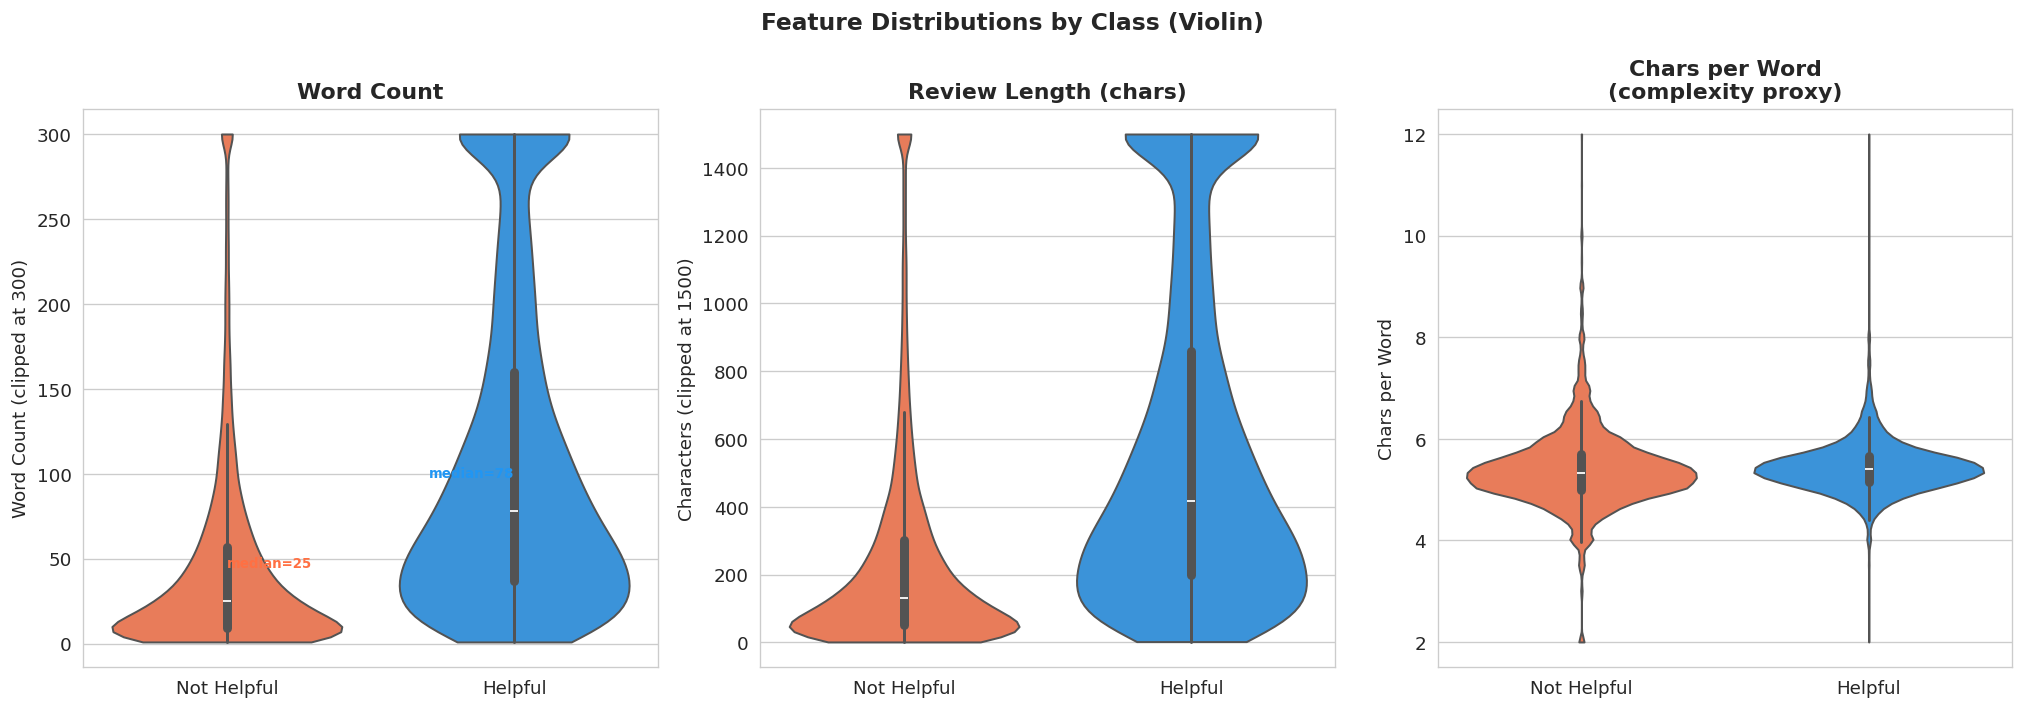


Median values by class:
  Feature               Not Helpful      Helpful   Difference
  ----------------------------------------------------------
  Word Count                   25.0         78.0        +53.0
  Review Length               131.0        418.0       +287.0
  Chars/Word                    5.3          5.4         +0.1


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('Feature Distributions by Class (Violin)', fontsize=14, fontweight='bold')

vdf = df.copy()
vdf['Class'] = vdf['helpful_binary'].map({0: 'Not Helpful', 1: 'Helpful'})
vpal = {'Not Helpful': PALETTE['not_helpful'], 'Helpful': PALETTE['helpful']}

# Word count
ax = axes[0]
vdf['word_count_clipped'] = vdf['word_count'].clip(upper=300)
sns.violinplot(data=vdf, x='Class', y='word_count_clipped', palette=vpal,
               ax=ax, inner='box', cut=0, linewidth=1.2)
ax.set_title('Word Count', fontweight='bold')
ax.set_ylabel('Word Count (clipped at 300)')
ax.set_xlabel('')
for cls, color in [('Not Helpful', PALETTE['not_helpful']), ('Helpful', PALETTE['helpful'])]:
    med = vdf[vdf['Class']==cls]['word_count'].median()
    ax.annotate(f'median={med:.0f}', xy=(0 if cls=='Not Helpful' else 1, med),
                xytext=(0.15 if cls=='Not Helpful' else 0.85, med + 20),
                fontsize=8, ha='center', color=color, fontweight='bold')

# Review length
ax = axes[1]
vdf['rev_len_clipped'] = vdf['review_length'].clip(upper=1500)
sns.violinplot(data=vdf, x='Class', y='rev_len_clipped', palette=vpal,
               ax=ax, inner='box', cut=0, linewidth=1.2)
ax.set_title('Review Length (chars)', fontweight='bold')
ax.set_ylabel('Characters (clipped at 1500)')
ax.set_xlabel('')

# Chars per word
ax = axes[2]
vdf['cpw_clipped'] = vdf['chars_per_word'].clip(2, 12)
sns.violinplot(data=vdf, x='Class', y='cpw_clipped', palette=vpal,
               ax=ax, inner='box', cut=0, linewidth=1.2)
ax.set_title('Chars per Word\n(complexity proxy)', fontweight='bold')
ax.set_ylabel('Chars per Word')
ax.set_xlabel('')

plt.tight_layout()
plt.show()

# Summary stats table
print('\nMedian values by class:')
print(f'  {"Feature":<20} {"Not Helpful":>12} {"Helpful":>12} {"Difference":>12}')
print('  ' + '-'*58)
for col, label in [('word_count','Word Count'), ('review_length','Review Length'), ('chars_per_word','Chars/Word')]:
    m0 = df[df['helpful_binary']==0][col].median()
    m1 = df[df['helpful_binary']==1][col].median()
    print(f'  {label:<20} {m0:>12.1f} {m1:>12.1f} {m1-m0:>+12.1f}')

---
## 13. Temporal Train/Test Split

Visualise the recommended split to confirm class balance is preserved on both sides.

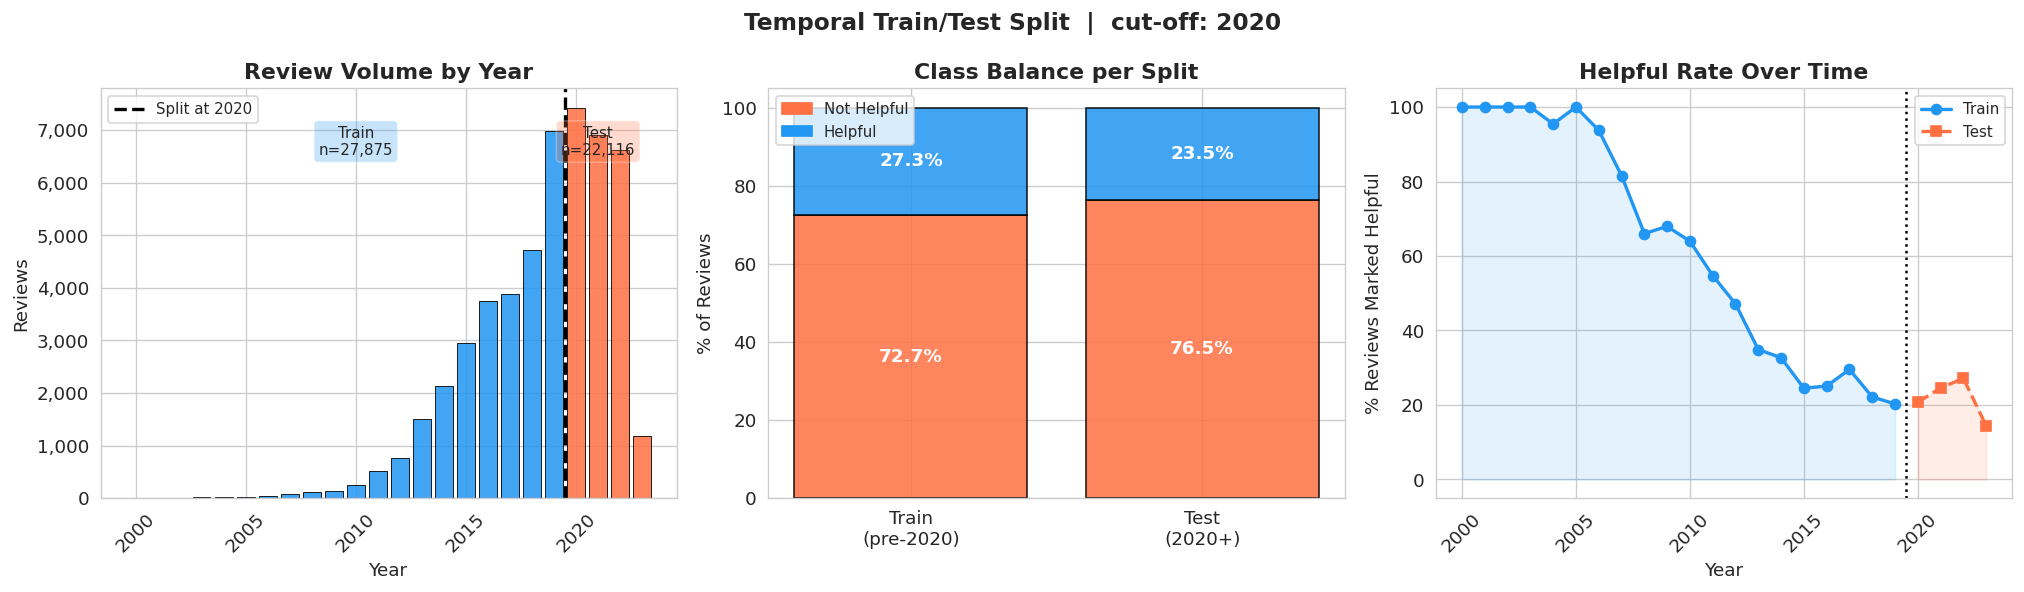


Temporal Split Summary:
  Train  (pre-2020): 27,875 reviews | Helpful: 27.3%
  Test   (2020+):    22,116 reviews  | Helpful: 23.5%
  Class balance shift: 3.8 pp


In [14]:
SPLIT_YEAR = 2020

year_df    = df[df['year'].between(2000, 2023)].copy()
train_df   = year_df[year_df['year'] <  SPLIT_YEAR]
test_df    = year_df[year_df['year'] >= SPLIT_YEAR]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f'Temporal Train/Test Split  |  cut-off: {SPLIT_YEAR}', fontsize=14, fontweight='bold')

# 13a. Volume by year, coloured by split
ax = axes[0]
vol = year_df.groupby('year').size()
bar_colors = [PALETTE['helpful'] if y < SPLIT_YEAR else PALETTE['not_helpful'] for y in vol.index]
ax.bar(vol.index, vol.values, color=bar_colors, edgecolor='black', alpha=0.85, linewidth=0.6)
ax.axvline(SPLIT_YEAR - 0.5, color='black', linestyle='--', linewidth=2, label=f'Split at {SPLIT_YEAR}')
ax.set_title('Review Volume by Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Reviews')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.text(2010, vol.max()*0.88, f'Train\nn={len(train_df):,}', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor=PALETTE['helpful'], alpha=0.25))
ax.text(2021, vol.max()*0.88, f'Test\nn={len(test_df):,}', ha='center', fontsize=9,
        bbox=dict(boxstyle='round', facecolor=PALETTE['not_helpful'], alpha=0.25))

# 13b. Class balance per split (stacked bar)
ax = axes[1]
for i, (split_name, split_data) in enumerate([('Train\n(pre-2020)', train_df),
                                               ('Test\n(2020+)',     test_df)]):
    hr  = split_data['helpful_binary'].mean() * 100
    nhr = 100 - hr
    ax.bar(i, nhr, color=PALETTE['not_helpful'], edgecolor='black', alpha=0.85)
    ax.bar(i, hr,  bottom=nhr, color=PALETTE['helpful'], edgecolor='black', alpha=0.85)
    ax.text(i, nhr/2,       f'{nhr:.1f}%', ha='center', va='center', fontsize=11,
            fontweight='bold', color='white')
    ax.text(i, nhr + hr/2,  f'{hr:.1f}%',  ha='center', va='center', fontsize=11,
            fontweight='bold', color='white')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Train\n(pre-2020)', 'Test\n(2020+)'])
ax.set_title('Class Balance per Split', fontweight='bold')
ax.set_ylabel('% of Reviews')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=PALETTE['not_helpful'], label='Not Helpful'),
                   Patch(color=PALETTE['helpful'],     label='Helpful')], fontsize=9)

# 13c. Helpful rate over time, coloured by split
ax = axes[2]
hr_year = year_df.groupby('year')['helpful_binary'].mean() * 100
train_yr = hr_year[hr_year.index <  SPLIT_YEAR]
test_yr  = hr_year[hr_year.index >= SPLIT_YEAR]
ax.plot(train_yr.index, train_yr.values, 'o-', color=PALETTE['helpful'],
        linewidth=2, markersize=6, label='Train')
ax.plot(test_yr.index,  test_yr.values,  's--', color=PALETTE['not_helpful'],
        linewidth=2, markersize=6, label='Test')
ax.axvline(SPLIT_YEAR - 0.5, color='black', linestyle=':', linewidth=1.5)
ax.fill_between(train_yr.index, train_yr.values, alpha=0.12, color=PALETTE['helpful'])
ax.fill_between(test_yr.index,  test_yr.values,  alpha=0.12, color=PALETTE['not_helpful'])
ax.set_title('Helpful Rate Over Time', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% Reviews Marked Helpful')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'\nTemporal Split Summary:')
print(f'  Train  (pre-{SPLIT_YEAR}): {len(train_df):,} reviews | Helpful: {train_df["helpful_binary"].mean()*100:.1f}%')
print(f'  Test   ({SPLIT_YEAR}+):    {len(test_df):,} reviews  | Helpful: {test_df["helpful_binary"].mean()*100:.1f}%')
print(f'  Class balance shift: {abs(train_df["helpful_binary"].mean() - test_df["helpful_binary"].mean())*100:.1f} pp')

---
## 9. Modelling Implications

Summary of visual findings and their direct impact on model design.

In [15]:
print('MODELLING IMPLICATIONS')
print('=' * 70)

n_helpful     = df['helpful_binary'].sum()
n_not_helpful = len(df) - n_helpful
ratio         = n_not_helpful / n_helpful

print(f'''
1. CLASS IMBALANCE
   Not Helpful: {n_not_helpful:,} ({n_not_helpful/len(df)*100:.1f}%)
   Helpful:     {n_helpful:,} ({n_helpful/len(df)*100:.1f}%)
   Ratio:       {ratio:.2f}:1
   → Use class_weight="balanced", stratified sampling, or focal loss.
   → Prioritise F1/AUC-ROC over accuracy as evaluation metric.

2. TEXT FEATURES (strongest signal)
   Helpful reviews are longer (median word count higher).
   Long review flag (>200 words) differentiates classes.
   → Include review_length, word_count, chars_per_word as features.
   → TF-IDF or sentence embeddings on review text are likely high-value.

3. RATING SIGNAL
   1-star and 2-star reviews have higher helpful rates.
   Negative reviews are read more carefully by other customers.
   → Rating and sentiment label are useful metadata features.

4. VERIFIED PURCHASE
   Non-verified purchases have higher helpful rates — customers trust
   detailed reviews regardless of purchase verification.
   → Include verified_purchase as a binary feature.

5. TEMPORAL BIAS
   Older reviews accumulate more votes — year is a confound.
   → Use temporal train/test split (e.g. train pre-2020, test post-2020)
     rather than random split to avoid data leakage.
   → Consider year as a feature or normalise helpful_vote by age.

6. FEATURE SUMMARY FOR BASELINE MODEL:
   ┌─────────────────────┬────────────────────────────────┐
   │ Feature             │ Type                           │
   ├─────────────────────┼────────────────────────────────┤
   │ review_length       │ Numeric                        │
   │ word_count          │ Numeric                        │
   │ chars_per_word      │ Numeric (complexity proxy)     │
   │ is_long             │ Binary flag                    │
   │ rating              │ Ordinal / Numeric              │
   │ verified_purchase   │ Binary                         │
   │ year                │ Numeric (temporal signal)      │
   │ review text (TF-IDF │ Sparse/Dense text features     │
   │  or embeddings)     │                                │
   └─────────────────────┴────────────────────────────────┘
''')

MODELLING IMPLICATIONS

1. CLASS IMBALANCE
   Not Helpful: 37,168 (74.3%)
   Helpful:     12,823 (25.7%)
   Ratio:       2.90:1
   → Use class_weight="balanced", stratified sampling, or focal loss.
   → Prioritise F1/AUC-ROC over accuracy as evaluation metric.

2. TEXT FEATURES (strongest signal)
   Helpful reviews are longer (median word count higher).
   Long review flag (>200 words) differentiates classes.
   → Include review_length, word_count, chars_per_word as features.
   → TF-IDF or sentence embeddings on review text are likely high-value.

3. RATING SIGNAL
   1-star and 2-star reviews have higher helpful rates.
   Negative reviews are read more carefully by other customers.
   → Rating and sentiment label are useful metadata features.

4. VERIFIED PURCHASE
   Non-verified purchases have higher helpful rates — customers trust
   detailed reviews regardless of purchase verification.
   → Include verified_purchase as a binary feature.

5. TEMPORAL BIAS
   Older reviews accumulate